# Assumptions of linear regression

- 1. Linear relationship between input and output variables
  2. No multicollinearity
  3. Normality of residual
  4. Homoscedasticity
  5. No Auto-correlation of erros

#### 1. linear relationship b/w input and output variables

In [2]:
import pandas as pd
df = pd.read_csv("data.csv")

In [3]:
df.shape

(200, 4)

In [4]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [5]:
X = df.iloc[:, 0:3].values
y = df.iloc[:,3].values

In [7]:
X

array([[-5.70562824e-01,  1.42034231e+00,  4.95580395e-01],
       [-9.90562704e-01,  5.56964528e-01,  1.04506399e+00],
       [-6.74727510e-01,  1.50616865e-01,  1.77464503e+00],
       [ 3.88250414e-01, -3.87127181e-01, -1.10229155e-01],
       [ 1.16788229e+00, -2.41044701e-02,  1.45063214e-01],
       [-8.89888979e-01, -1.58094538e+00, -4.22792727e-01],
       [-2.68510868e+00,  1.84207947e-02,  1.72266920e+00],
       [ 6.63187770e-01,  1.85267835e-01, -1.88342383e+00],
       [ 3.19196176e-01, -2.98397020e+00, -1.51521566e+00],
       [-3.48368316e-01, -1.81101917e+00,  7.46891531e-01],
       [-6.37134863e-01, -5.39574612e-01, -4.08345242e-01],
       [ 1.11594518e+00, -3.03033672e-02, -3.19590141e-01],
       [-6.89599657e-01, -3.57440729e-01, -5.41503716e-01],
       [ 2.07087853e+00,  1.06979836e+00,  5.93588115e-01],
       [-7.12849796e-01, -1.50891712e+00, -2.52815988e-01],
       [ 8.87925723e-01, -8.23886105e-01,  4.36232115e-01],
       [-2.94033248e-01, -6.87859510e-01

In [9]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
# residual
y_pred = lr.predict(X_test)
residual = y_test - y_pred

In [15]:
# 1. linear relationship

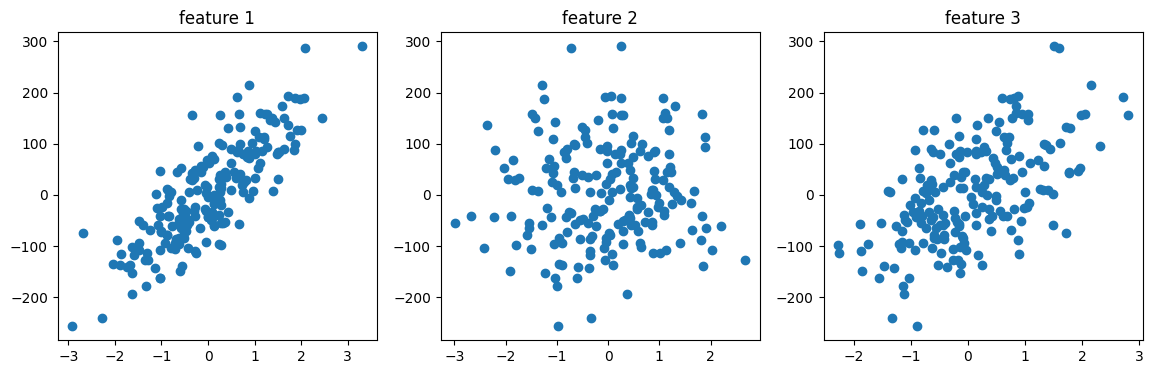

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))

plt.subplot(131)
plt.scatter(df["feature1"], df["target"])
plt.title("feature 1")

plt.subplot(132)
plt.scatter(df["feature2"], df["target"])
plt.title("feature 2")

plt.subplot(133)
plt.scatter(df["feature3"], df["target"])
plt.title("feature 3")

plt.show()

In [22]:
# feature 1 has linear relationship
# feature 2 has non linear relationship
# fetaure 3 has slightly linear relationship

#### 2. Multicollinearity

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [25]:
vif

[1.007859496215283, 1.0029388373336066, 1.0050133036773625]

In [28]:
pd.DataFrame({"vif" : vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.007859,1.002939,1.005013


In [29]:
# Here the vif is 1 but if it will 5 or more than 5 then 
# we should remove that feature because that is collinear with other features

In [30]:
# Another technique

<Axes: >

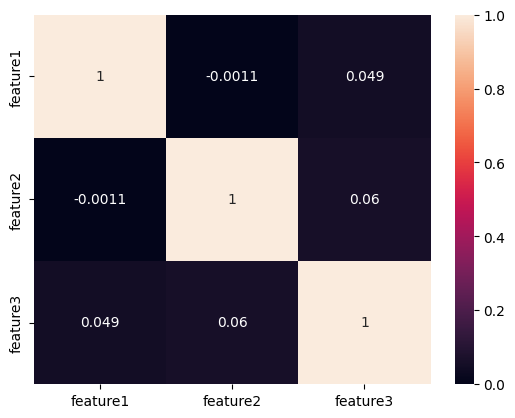

In [32]:
import seaborn as sns
sns.heatmap(df.iloc[:,0:3].corr(), annot=True)

#### 3. Normal Residual

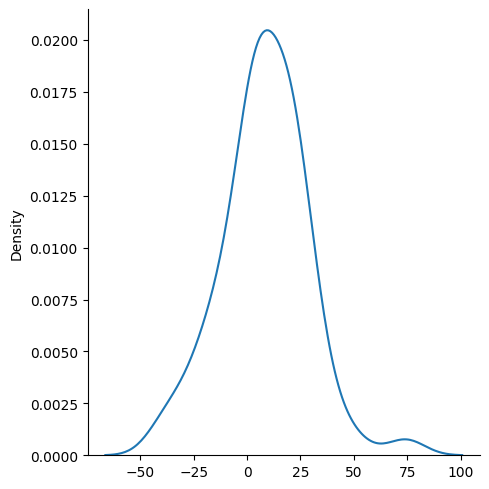

In [34]:
# residual means difference between actual values and predicted values
# the assumption is when we plot residual then it should be normal
sns.displot(residual, kind="kde")

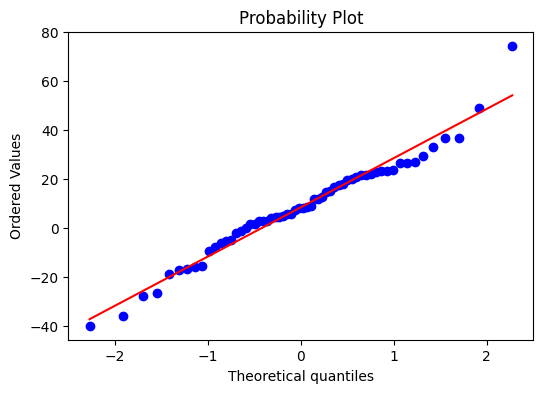

In [38]:
## QQ plot
# the blue points should be on the line as much as possible

import scipy as sp

fig, ax = plt.subplots(figsize=(6, 4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

#### 4. Homoscedasticity

In [39]:
# Homo - means same
# scedasticity - means spread
# having the same scatter(spread)

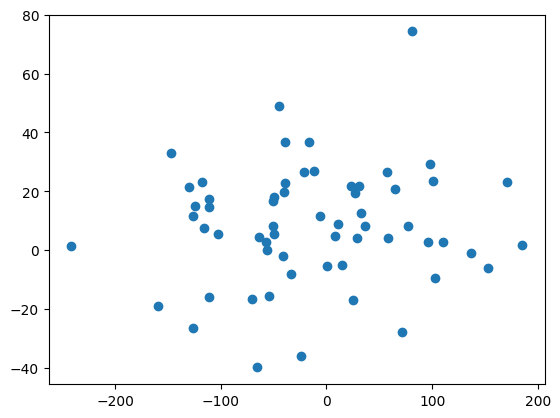

In [40]:
plt.scatter(y_pred, residual)

#### 5. No Auto-correlation of erros

In [41]:
# when we plot our all the residuals then there should not be any pattern forms in the plot

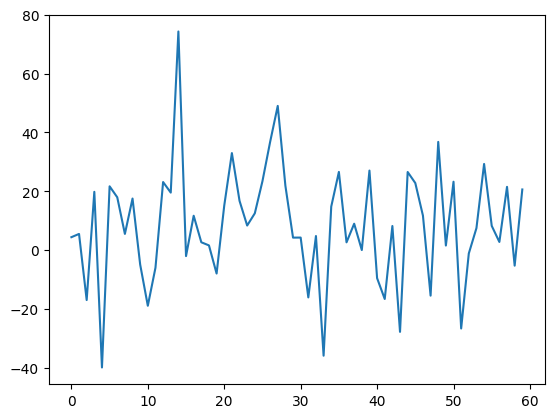

In [42]:
plt.plot(residual)